# 📘 Suite du TP – Analyse des performances d’étudiants

🎯 **Objectif :** Approfondir la préparation du dataset pour une régression linéaire multiple en appliquant la standardisation, la réduction de dimension et la suppression des variables corrélées.

## 🔄 7. Normalisation et standardisation

**0** Comprendre la notion de normalisation et de standardisation 

**21.** Standardisez toutes les colonnes numériques de `X` (moyenne 0, écart-type 1) à l’aide de `StandardScaler`.

**22.** Comparez les résultats avec une normalisation min-max (`MinMaxScaler`).

## 🔁 8. Suppression des variables trop corrélées

**0.** Comprendre la notion de corrélation linéaire. 

**23.** Calculez la **matrice de corrélation** entre les variables explicatives (`X`).

**24.** Supprimez les variables dont la corrélation dépasse un seuil (ex : > 0.9).

**25.** Réaffichez la heatmap pour valider.

## 🧬 9. Réduction de dimension (PCA)

**0.** Comprendre la notion de réduction de dimension. Essayer de comprendre PCA globalement

**26.** Appliquez une **PCA** sur les données standardisées.

**27.** Affichez la variance expliquée par chaque composante.

**28.** Tracez un nuage de points 2D selon les 2 premières composantes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# On recharge X et y sauvegardés à la fin du TP précédent
X = pd.read_csv("../data/X_students.csv")
y = pd.read_csv("../data/y_students.csv")["average_score"]

X.head()
# Raison : on repart de X/y déjà nettoyés et encodés (numériques) pour ne pas
# refaire tout le prétraitement -> continuité directe avec le TP précédent.

ModuleNotFoundError: No module named 'sklearn'

**Réponse – Comprendre normalisation / standardisation**

- **Normalisation (min-max)** : ramène chaque variable dans un intervalle fixe, en général `[0, 1]`, via la formule `(x - min) / (max - min)`. Utile quand on connaît les bornes et qu'on veut préserver la forme de la distribution d'origine.
- **Standardisation (z-score)** : centre chaque variable sur une moyenne de 0 et une variance de 1, via `(x - moyenne) / écart-type`. Elle ne borne pas les valeurs dans un intervalle fixe et est plus robuste aux valeurs extrêmes (outliers) que le min-max.
- **Pourquoi c'est nécessaire ici ?** Une régression linéaire multiple (et surtout la PCA plus loin) est sensible à l'échelle des variables : sans standardisation, les colonnes avec de grandes valeurs domineraient artificiellement le modèle/les axes de variance.

In [ ]:
# 21. Standardisation (StandardScaler) : moyenne 0, écart-type 1
scaler_std = StandardScaler()
X_standardized = pd.DataFrame(
    scaler_std.fit_transform(X), columns=X.columns
)

print("Moyennes après standardisation (≈ 0) :")
print(X_standardized.mean().round(6))
print("\nÉcarts-types après standardisation (≈ 1) :")
print(X_standardized.std(ddof=0).round(6))

X_standardized.head()
# Raison : StandardScaler().fit_transform() calcule (x - moyenne) / écart-type
# pour chaque colonne. On vérifie le résultat en réaffichant moyenne (≈0) et
# écart-type (≈1) de chaque colonne standardisée.

Moyennes après standardisation (≈ 0) :
gender                                           -0.0
race/ethnicity_group A                           -0.0
race/ethnicity_group B                            0.0
race/ethnicity_group C                           -0.0
parental level of education_associate's degree   -0.0
parental level of education_bachelor's degree    -0.0
parental level of education_master's degree      -0.0
parental level of education_some college         -0.0
lunch_free/reduced                               -0.0
lunch_standard                                    0.0
test preparation course_completed                -0.0
test preparation course_none                      0.0
dtype: float64

Écarts-types après standardisation (≈ 1) :
gender                                            1.0
race/ethnicity_group A                            1.0
race/ethnicity_group B                            1.0
race/ethnicity_group C                            1.0
parental level of education_associate'

,gender,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_master's degree,parental level of education_some college,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,-0.577350,-0.577350,1.0,-0.577350,-0.577350,1.732051,-0.577350,-0.577350,-0.577350,0.577350,-0.577350,0.577350
1,-0.577350,-0.577350,-1.0,1.732051,-0.577350,-0.577350,-0.577350,1.732051,-0.577350,0.577350,1.732051,-1.732051
2,-0.577350,-0.577350,1.0,-0.577350,-0.577350,-0.577350,1.732051,-0.577350,-0.577350,0.577350,-0.577350,0.577350
3,1.732051,1.732051,-1.0,-0.577350,1.732051,-0.577350,-0.577350,-0.577350,1.732051,-1.732051,-0.577350,0.577350


In [ ]:
# 22. Normalisation min-max (MinMaxScaler), à comparer avec la standardisation
scaler_minmax = MinMaxScaler()
X_normalized = pd.DataFrame(
    scaler_minmax.fit_transform(X), columns=X.columns
)

print("Min après normalisation (= 0) :")
print(X_normalized.min())
print("\nMax après normalisation (= 1) :")
print(X_normalized.max())

X_normalized.head()
# Comparaison :
# - StandardScaler -> valeurs centrées sur 0, pas de bornes fixes (peuvent
#   dépasser -3/+3 si outliers).
# - MinMaxScaler   -> valeurs toujours dans [0, 1], mais très sensible aux
#   valeurs extrêmes (un seul outlier écrase l'échelle de toute la colonne).
# Avec seulement 4 lignes, beaucoup de colonnes binaires (one-hot) ont déjà
# leurs valeurs dans {0,1} : min-max ne change presque rien pour elles,
# l'effet est surtout visible sur une variable continue (ici il n'y en a
# pas dans X, tout est déjà catégoriel encodé).

Min après normalisation (= 0) :
gender                                            0.0
race/ethnicity_group A                            0.0
race/ethnicity_group B                            0.0
race/ethnicity_group C                            0.0
parental level of education_associate's degree    0.0
parental level of education_bachelor's degree     0.0
parental level of education_master's degree       0.0
parental level of education_some college          0.0
lunch_free/reduced                                0.0
lunch_standard                                    0.0
test preparation course_completed                 0.0
test preparation course_none                      0.0
dtype: float64

Max après normalisation (= 1) :
gender                                            1.0
race/ethnicity_group A                            1.0
race/ethnicity_group B                            1.0
race/ethnicity_group C                            1.0
parental level of education_associate's degree    1.0
pa

,gender,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_master's degree,parental level of education_some college,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


**Réponse – Comprendre la corrélation linéaire**

La corrélation de Pearson mesure à quel point deux variables varient ensemble de façon **linéaire**, entre -1 et 1 :
- proche de **+1** : les deux variables augmentent ensemble ;
- proche de **-1** : quand l'une augmente, l'autre diminue ;
- proche de **0** : pas de relation linéaire détectable.

**Pourquoi supprimer les variables trop corrélées ?** Deux variables très corrélées (ex. > 0.9) apportent presque la même information. Les garder toutes les deux peut créer de la **multicolinéarité**, qui rend les coefficients d'une régression linéaire instables et difficiles à interpréter, sans réellement améliorer la capacité prédictive du modèle.

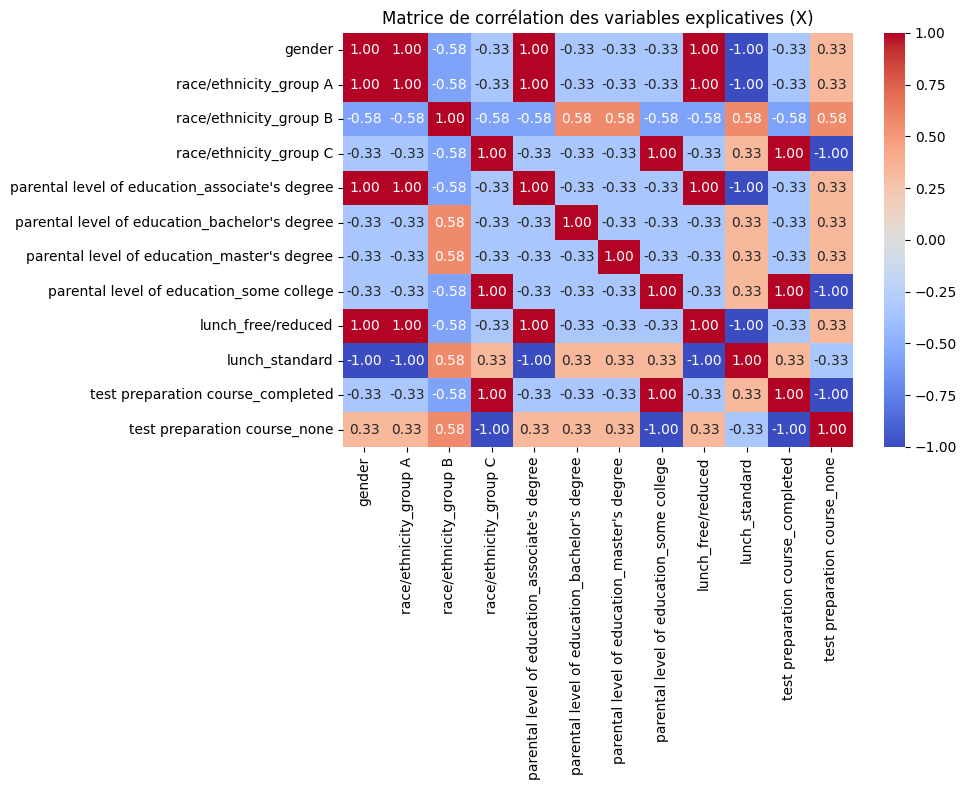

In [ ]:
# 23. Matrice de corrélation entre les variables explicatives (X)
corr_matrix = X_standardized.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables explicatives (X)")
plt.tight_layout()
plt.show()
# Raison : .corr() sur X (standardisé ou non, le résultat est identique car
# la corrélation est invariante par changement d'échelle linéaire).
# ⚠️ Avec 4 lignes seulement, plusieurs colonnes one-hot (ex. gender,
# race/ethnicity_group A, lunch_free/reduced...) sont parfaitement corrélées
# (±1) simplement parce qu'un seul étudiant possède cette combinaison de
# caractéristiques -> coïncidence liée au petit échantillon, pas une vraie
# relation structurelle. Sur 1000 lignes ce sera beaucoup plus nuancé.

In [ ]:
# 24. Suppression des variables dont la corrélation dépasse un seuil (0.9)
threshold = 0.9

corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print("Colonnes supprimées (corrélation > 0.9 avec une autre) :", to_drop)

X_reduced = X_standardized.drop(columns=to_drop)
print(f"\nNombre de colonnes avant : {X_standardized.shape[1]}, après : {X_reduced.shape[1]}")
X_reduced.head()
# Raison : on ne regarde que le triangle supérieur de la matrice de
# corrélation (np.triu avec k=1) pour éviter de compter deux fois chaque
# paire (corr(A,B) == corr(B,A)) et d'éviter la diagonale (corr(A,A)=1).
# Pour chaque paire dépassant le seuil, on supprime une seule des deux
# colonnes (celle rencontrée en second dans l'ordre des colonnes).

Colonnes supprimées (corrélation > 0.9 avec une autre) : ['race/ethnicity_group A', "parental level of education_associate's degree", 'parental level of education_some college', 'lunch_free/reduced', 'lunch_standard', 'test preparation course_completed', 'test preparation course_none']

Nombre de colonnes avant : 12, après : 5


,gender,race/ethnicity_group B,race/ethnicity_group C,parental level of education_bachelor's degree,parental level of education_master's degree
0,-0.577350,1.0,-0.577350,1.732051,-0.577350
1,-0.577350,-1.0,1.732051,-0.577350,-0.577350
2,-0.577350,1.0,-0.577350,-0.577350,1.732051
3,1.732051,-1.0,-0.577350,-0.577350,-0.577350


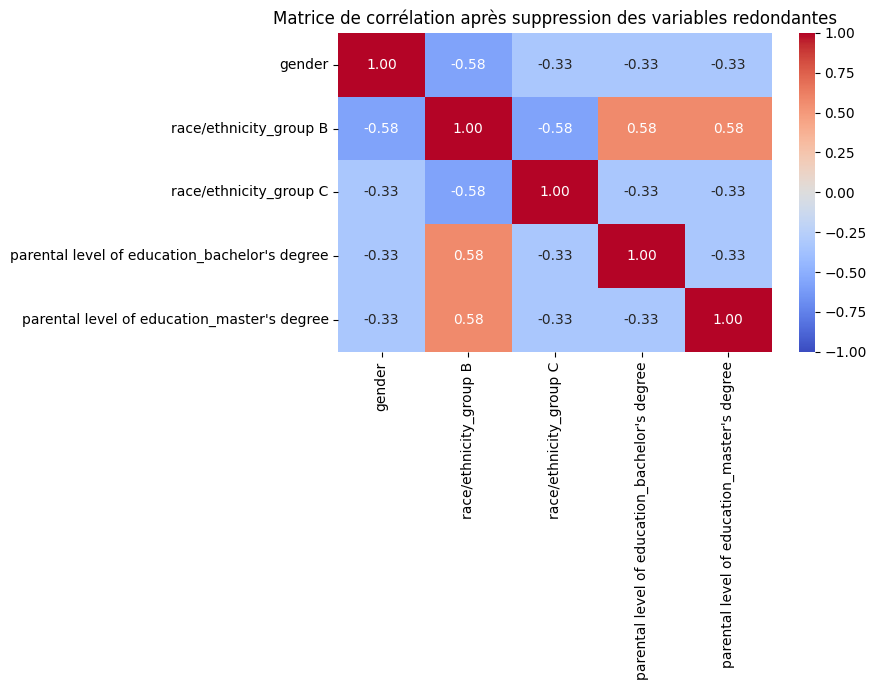

In [ ]:
# 25. Heatmap après suppression, pour validation
plt.figure(figsize=(9, 7))
sns.heatmap(X_reduced.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation après suppression des variables redondantes")
plt.tight_layout()
plt.show()
# Raison : on revérifie visuellement qu'il ne reste plus de paire de
# variables avec une corrélation extrême (>0.9 ou <-0.9) dans X_reduced.

**Réponse – Comprendre la réduction de dimension et la PCA**

La **réduction de dimension** consiste à représenter les données avec moins de colonnes tout en gardant le maximum d'information (de variance). Elle est utile pour visualiser des données à plus de 2-3 dimensions, réduire le bruit/la redondance, et accélérer l'entraînement des modèles.

La **PCA (Analyse en Composantes Principales)** construit de nouveaux axes (les *composantes principales*), combinaisons linéaires des variables d'origine, **non corrélées entre elles**, et ordonnées par variance expliquée décroissante : la 1ère composante capture le plus de variance possible, la 2ème le maximum de variance restante (orthogonale à la 1ère), etc. On peut alors ne garder que les premières composantes qui résument l'essentiel de l'information.

In [ ]:
# 26. PCA sur les données standardisées
# Avec seulement 4 échantillons, le nombre max de composantes est min(n_samples, n_features)
n_components = min(X_standardized.shape[0], X_standardized.shape[1])
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_standardized)

X_pca_df = pd.DataFrame(
    X_pca, columns=[f"PC{i+1}" for i in range(n_components)]
)
X_pca_df
# Raison : PCA().fit_transform() standardise déjà l'orientation des axes
# (on lui passe X_standardized car la PCA est sensible à l'échelle des
# variables, comme la standardisation vue à l'étape 21).
# ⚠️ n_components est limité ici à 4 (nombre d'échantillons) au lieu des
# 12 variables d'origine, à cause du petit jeu de données.

,PC1,PC2,PC3,PC4
0,-0.751171,2.025441,1.632993e+00,5.478011e-16
1,-2.591156,-2.935855,-3.671295e-18,5.478011e-16
2,-0.751171,2.025441,-1.632993e+00,5.478011e-16
3,4.093497,-1.115026,4.736625e-16,5.478011e-16


PC1 : 51.25% de variance expliquée (cumulé : 51.25%)
PC2 : 37.64% de variance expliquée (cumulé : 88.89%)
PC3 : 11.11% de variance expliquée (cumulé : 100.00%)
PC4 : 0.00% de variance expliquée (cumulé : 100.00%)


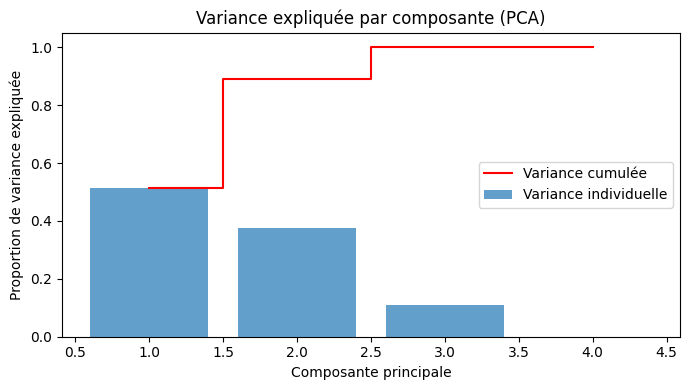

In [ ]:
# 27. Variance expliquée par chaque composante
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

for i, (v, c) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"PC{i} : {v*100:.2f}% de variance expliquée (cumulé : {c*100:.2f}%)")

plt.figure(figsize=(7, 4))
plt.bar(range(1, n_components + 1), explained_var, alpha=0.7, label="Variance individuelle")
plt.step(range(1, n_components + 1), cumulative_var, where="mid", color="red", label="Variance cumulée")
plt.xlabel("Composante principale")
plt.ylabel("Proportion de variance expliquée")
plt.title("Variance expliquée par composante (PCA)")
plt.legend()
plt.tight_layout()
plt.show()
# Raison : pca.explained_variance_ratio_ donne directement, pour chaque
# composante, la proportion de la variance totale des données qu'elle capture.
# Le graphique (éboulis + courbe cumulée) aide à choisir combien de
# composantes garder (ex. celles qui cumulent 90-95% de variance).

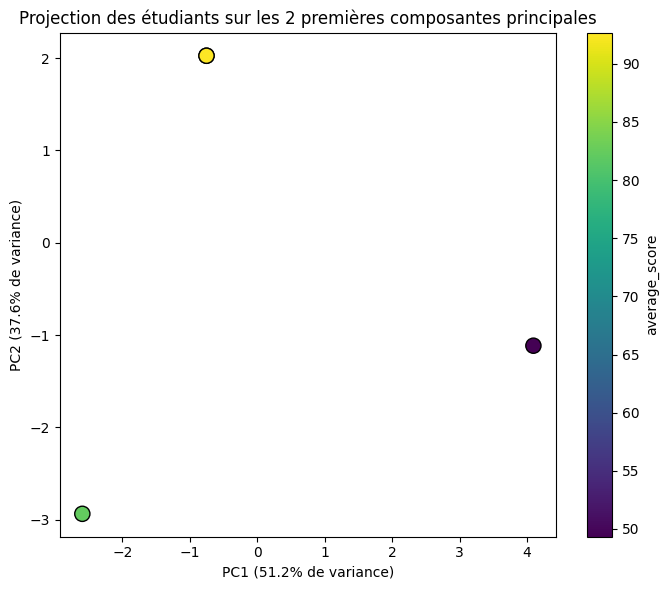

In [ ]:
# 28. Nuage de points 2D selon les 2 premières composantes principales
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_pca_df["PC1"], X_pca_df["PC2"],
    c=y, cmap="viridis", s=120, edgecolor="black"
)
plt.colorbar(scatter, label="average_score")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% de variance)")
plt.title("Projection des étudiants sur les 2 premières composantes principales")
plt.tight_layout()
plt.show()
# Raison : on projette chaque étudiant sur le plan (PC1, PC2), les 2 axes
# qui résument le plus de variance des données. La couleur (average_score)
# permet de voir si la séparation sur ce plan correspond à une tendance de
# performance scolaire.
# ⚠️ Avec 4 points seulement, ce nuage ne permet aucune interprétation
# fiable (aucun cluster/tendance ne peut être validé statistiquement) -
# à refaire impérativement sur le dataset complet de 1000 étudiants.